STEP 1: Mount Google Drive & Dataset Setup

In [1]:
# STEP 1: Mount Google Drive & Download/Extract Dataset

import os
import zipfile
import shutil
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# Define paths
download_url = "https://prod-dcd-datasets-cache-zipfiles.s3.eu-west-1.amazonaws.com/ptz377bwb8-1.zip"
archive_path = "/content/PotatoDiseaseDataset.zip"
extract_path = "/content/PotatoDiseaseDataset"
dest_path = "/content/drive/My Drive/Research/PotatoDiseaseDataset"

# Download and extract if not exists in Drive
if not os.path.exists(dest_path):
    print("Downloading and extracting dataset...")
    os.system(f"wget -O {archive_path} {download_url}")
    with zipfile.ZipFile(archive_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    os.makedirs(os.path.dirname(dest_path), exist_ok=True)
    shutil.move(extract_path, dest_path)
    print("Dataset downloaded, extracted, and moved to Google Drive.")
else:
    print(f"Destination path '{dest_path}' already exists. Skipping move.")

# Check final data_dir and print class stats
data_dir = os.path.join(dest_path, "Potato Leaf Disease Dataset in Uncontrolled Environment")
print("\nClasses inside actual dataset folder:")
class_names = sorted(os.listdir(data_dir))
for c in class_names:
    class_dir = os.path.join(data_dir, c)
    n_imgs = len([f for f in os.listdir(class_dir) if f.lower().endswith(('.jpg', '.png', '.jpeg'))])
    print(f"{c:15}: {n_imgs} images")

# Print total images
total_imgs = sum(
    len([f for f in os.listdir(os.path.join(data_dir, c)) if f.lower().endswith(('.jpg', '.png', '.jpeg'))])
    for c in class_names
)
print(f"\nTotal images in dataset: {total_imgs}\n")


Mounted at /content/drive
Destination path '/content/drive/My Drive/Research/PotatoDiseaseDataset' already exists. Skipping move.

Classes inside actual dataset folder:
Bacteria       : 569 images
Fungi          : 748 images
Healthy        : 201 images
Nematode       : 68 images
Pest           : 611 images
Phytopthora    : 347 images
Virus          : 532 images

Total images in dataset: 3076



# STEP 2: Install Required Packages & Import Libraries

In [2]:
# STEP 2: Install Required Packages & Import Libraries

# Install latest timm first (ALWAYS before importing timm)
!pip install -U timm

# --- Core Libraries ---
import os
import shutil
import numpy as np
import random
import sys
import traceback
from pathlib import Path

# --- PyTorch and Data ---
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split, WeightedRandomSampler
from torchvision import transforms, datasets

# --- Models and Augmentations ---
import timm
from timm.loss import LabelSmoothingCrossEntropy
from timm.data import Mixup

# --- Evaluation ---
from sklearn.metrics import precision_recall_fscore_support, confusion_matrix

# --- Visualization ---
import matplotlib.pyplot as plt
import seaborn as sns

# --- Utilities ---
import pandas as pd
from tqdm import tqdm
from PIL import Image
import logging
from collections import Counter

# CUDA check and device setup
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("All libraries imported successfully!")
print("Torch version:", torch.__version__)
print("Using device:", device)


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.9/59.9 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 98.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 97.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 71.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 57.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 104.7 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12

# STEP 3: Utility Classes, CBAM, Dataset Validation, Class Weights, Logging


In [3]:
# --- SafeImageFolder (robust dataset loader) ---
class SafeImageFolder(datasets.ImageFolder):
    def __init__(self, root, transform=None):
        super().__init__(root, transform=transform)
        self.invalid_files = []
    def __getitem__(self, index):
        path, target = self.samples[index]
        try:
            sample = self.loader(path)
            if self.transform is not None:
                sample = self.transform(sample)
            return sample, target
        except Exception as e:
            print(f"Error loading {path}: {e}")
            self.invalid_files.append(path)
            dummy = torch.zeros(3, 224, 224) if self.transform is None else self.transform(Image.new('RGB', (224, 224)))
            return dummy, -1
    def __len__(self):
        return len(self.samples)

# --- EarlyStopping ---
class EarlyStopping:
    def __init__(self, patience=10, delta=0, verbose=True, path='checkpoint.pt'):
        self.patience = patience
        self.delta = delta
        self.verbose = verbose
        self.path = path
        self.best_score = None
        self.early_stop = False
        self.counter = 0
        self.best_loss = float('inf')
    def __call__(self, val_loss, model):
        score = -val_loss
        if self.best_score is None:
            self.best_score = score
            self.save_checkpoint(val_loss, model)
        elif score < self.best_score + self.delta:
            self.counter += 1
            if self.verbose:
                print(f'EarlyStopping counter: {self.counter} out of {self.patience}')
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_score = score
            self.save_checkpoint(val_loss, model)
            self.counter = 0
    def save_checkpoint(self, val_loss, model):
        if self.verbose:
            print(f'Validation loss decreased ({self.best_loss:.4f} --> {val_loss:.4f}). Saving model ...')
        torch.save(model.state_dict(), self.path)
        self.best_loss = val_loss

# --- Dataset Validation ---
def validate_dataset(data_dir, class_names):
    print("Validating dataset...")
    total_images = 0
    for class_name in class_names:
        class_path = os.path.join(data_dir, class_name)
        if not os.path.exists(class_path):
            print(f"Warning: Class directory {class_path} does not exist")
            continue
        files = [f for f in os.listdir(class_path) if f.lower().endswith(('.jpg', '.png', '.jpeg'))]
        print(f"{class_name}: {len(files)} images found")
        total_images += len(files)
        for f in files:
            file_path = os.path.join(class_path, f)
            try:
                Image.open(file_path).verify()
            except Exception as e:
                print(f"Error: Corrupted image {file_path}: {e}")
    print(f"Dataset validation complete: {total_images} images found.")

# --- Class Weights (for loss and imbalance) ---
def compute_class_weights(dataset, num_classes):
    class_counts = [0] * num_classes
    for _, label in dataset:
        if label != -1:
            class_counts[label] += 1
    class_weights = [0.] * num_classes
    total = float(sum(class_counts))
    for i in range(num_classes):
        if class_counts[i] > 0:
            class_weights[i] = total / class_counts[i]
        else:
            class_weights[i] = 0.
    return torch.tensor(class_weights, dtype=torch.float32), class_counts

# --- Weighted Random Sampler for Imbalance ---
def get_sampler(dataset, num_classes, num_samples):
    targets = []
    for _, label in dataset:
        if label != -1:
            targets.append(label)
    class_sample_count = Counter(targets)
    weights = [1.0 / class_sample_count[t] for t in targets]
    sampler = WeightedRandomSampler(weights, num_samples, replacement=True)
    return sampler

# --- Logger Setup ---
def setup_logging(variant, output_dir):
    log_file = os.path.join(output_dir, f'training_{variant}.log')
    logger = logging.getLogger()
    logger.setLevel(logging.INFO)
    for handler in logger.handlers[:]:
        logger.removeHandler(handler)
    file_handler = logging.FileHandler(log_file)
    file_handler.setFormatter(logging.Formatter('%(asctime)s - %(levelname)s - %(message)s'))
    logger.addHandler(file_handler)
    console_handler = logging.StreamHandler()
    console_handler.setFormatter(logging.Formatter('%(asctime)s - %(levelname)s - %(message)s'))
    logger.addHandler(console_handler)
    return logger

# --- CBAM (Attention Module) ---
class BasicConv(nn.Module):
    def __init__(self, in_planes, out_planes, kernel_size, stride, padding=0, dilation=1, groups=1, relu=True, bn=True, bias=False):
        super(BasicConv, self).__init__()
        self.conv = nn.Conv2d(in_planes, out_planes, kernel_size=kernel_size, stride=stride,
                              padding=padding, dilation=dilation, groups=groups, bias=bias)
        self.bn = nn.BatchNorm2d(out_planes) if bn else None
        self.relu = nn.ReLU(inplace=True) if relu else None
    def forward(self, x):
        x = self.conv(x)
        if self.bn is not None: x = self.bn(x)
        if self.relu is not None: x = self.relu(x)
        return x

class ChannelAttention(nn.Module):
    def __init__(self, in_planes, ratio=8):
        super(ChannelAttention, self).__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)
        self.fc1 = nn.Conv2d(in_planes, in_planes // ratio, 1, bias=False)
        self.relu1 = nn.ReLU()
        self.fc2 = nn.Conv2d(in_planes // ratio, in_planes, 1, bias=False)
        self.sigmoid = nn.Sigmoid()
    def forward(self, x):
        avg_out = self.fc2(self.relu1(self.fc1(self.avg_pool(x))))
        max_out = self.fc2(self.relu1(self.fc1(self.max_pool(x))))
        out = avg_out + max_out
        return self.sigmoid(out)

class SpatialAttention(nn.Module):
    def __init__(self, kernel_size=7):
        super(SpatialAttention, self).__init__()
        padding = 3 if kernel_size == 7 else 1
        self.conv1 = nn.Conv2d(2, 1, kernel_size, padding=padding, bias=False)
        self.sigmoid = nn.Sigmoid()
    def forward(self, x):
        avg_out = torch.mean(x, dim=1, keepdim=True)
        max_out, _ = torch.max(x, dim=1, keepdim=True)
        x = torch.cat([avg_out, max_out], dim=1)
        x = self.conv1(x)
        return self.sigmoid(x)

class CBAM(nn.Module):
    def __init__(self, in_planes, ratio=8, kernel_size=7):
        super(CBAM, self).__init__()
        self.ca = ChannelAttention(in_planes, ratio)
        self.sa = SpatialAttention(kernel_size)
    def forward(self, x):
        x = x * self.ca(x)
        x = x * self.sa(x)
        return x

# --- DenseNet201 with CBAM ---
class DenseNet201WithCBAM(nn.Module):
    def __init__(self, num_classes=7, dropout=0.5, freeze_pct=0.1):
        super().__init__()
        from torchvision.models import densenet201
        densenet = densenet201(pretrained=True)
        # Freeze bottom layers for transfer learning (10%)
        total_layers = sum(1 for _ in densenet.features.parameters())
        freeze_layers = int(freeze_pct * total_layers)
        for i, param in enumerate(densenet.features.parameters()):
            if i < freeze_layers:
                param.requires_grad = False
        # Add CBAM after last DenseBlock
        self.features = densenet.features
        self.cbam = CBAM(1920, ratio=8)  # 1920 channels in DenseNet201 final feature map
        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(1920, num_classes)
    def forward(self, x):
        x = self.features(x)
        x = self.cbam(x)
        x = self.pool(x)
        x = torch.flatten(x, 1)
        x = self.dropout(x)
        x = self.classifier(x)
        return x

# --- Weighted Label Smoothing Loss (for reference, if NOT using MixUp) ---
class WeightedLabelSmoothingCrossEntropy(nn.Module):
    def __init__(self, weight=None, smoothing=0.1):
        super().__init__()
        self.smoothing = smoothing
        self.weight = weight  # tensor of shape (num_classes,) or None
    def forward(self, input, target):
        logprobs = torch.log_softmax(input, dim=-1)
        n_classes = input.size(-1)
        true_dist = torch.zeros_like(logprobs)
        true_dist.fill_(self.smoothing / (n_classes - 1))
        true_dist.scatter_(1, target.unsqueeze(1), 1.0 - self.smoothing)
        if self.weight is not None:
            weight = self.weight.unsqueeze(0)
            loss = - (true_dist * logprobs * weight).sum(dim=1)
        else:
            loss = - (true_dist * logprobs).sum(dim=1)
        return loss.mean()


# --- STEP 4: Transforms, Dataset, Imbalance Handling, DataLoader ---

In [4]:


# More aggressive augmentations can further help DenseNet regularization
train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.CenterCrop(224),
    transforms.RandomHorizontalFlip(0.5),
    transforms.RandomVerticalFlip(0.5),
    transforms.RandomRotation(40),   # slightly higher rotation range
    transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.3, hue=0.15),
    transforms.RandomAffine(0, translate=(0.12, 0.12)),  # increase translate
    transforms.GaussianBlur(3, sigma=(0.1, 2.0)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Load dataset (no transform yet)
dataset = SafeImageFolder(data_dir, transform=None)
class_names = dataset.classes
print(f"\nClass names: {class_names}")

# Print images per class (imbalance check)
cls_counts = [0] * len(class_names)
for _, label in dataset.samples:
    if label != -1:
        cls_counts[label] += 1
print("Image count per class:")
for cls, count in zip(class_names, cls_counts):
    print(f"{cls:15s} : {count}")

# Validate image files (detect corrupted)
validate_dataset(data_dir, class_names)

# Split (80/10/10)
train_ratio, val_ratio, test_ratio = 0.8, 0.1, 0.1
total_size = len(dataset)
train_size = int(train_ratio * total_size)
val_size = int(val_ratio * total_size)
test_size = total_size - train_size - val_size
print(f"\nDataset split - Train: {train_size}, Val: {val_size}, Test: {test_size}")

train_dataset, val_dataset, test_dataset = random_split(
    dataset, [train_size, val_size, test_size], generator=torch.Generator().manual_seed(42)
)
train_dataset.dataset.transform = train_transform
val_dataset.dataset.transform = val_transform
test_dataset.dataset.transform = val_transform

# Compute class weights (for loss)
class_weights, class_counts = compute_class_weights(train_dataset, len(class_names))
print("\nTrain set class counts:", class_counts)
print("Class weights (for loss):", class_weights.tolist())

# Weighted sampler (over/undersample to balance minibatches)
sampler = get_sampler(train_dataset, len(class_names), len(train_dataset))

batch_size = 16
train_loader = DataLoader(train_dataset, batch_size=batch_size, sampler=sampler, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

print(f"\nDataLoader setup complete!")
print(f"Number of train batches: {len(train_loader)}")
print(f"Number of val batches: {len(val_loader)}")
print(f"Number of test batches: {len(test_loader)}")



Class names: ['Bacteria', 'Fungi', 'Healthy', 'Nematode', 'Pest', 'Phytopthora', 'Virus']
Image count per class:
Bacteria        : 569
Fungi           : 748
Healthy         : 201
Nematode        : 68
Pest            : 611
Phytopthora     : 347
Virus           : 532
Validating dataset...
Bacteria: 569 images found
Fungi: 748 images found
Healthy: 201 images found
Nematode: 68 images found
Pest: 611 images found
Phytopthora: 347 images found
Virus: 532 images found
Dataset validation complete: 3076 images found.

Dataset split - Train: 2460, Val: 307, Test: 309

Train set class counts: [461, 599, 165, 49, 488, 277, 421]
Class weights (for loss): [5.336225509643555, 4.106844902038574, 14.909090995788574, 50.20408248901367, 5.0409836769104, 8.880866050720215, 5.843230247497559]

DataLoader setup complete!
Number of train batches: 154
Number of val batches: 20
Number of test batches: 20


MixUp function

In [5]:
import timm
import torch.nn as nn
from timm.data import Mixup
from timm.loss import SoftTargetCrossEntropy

# ---- MixUp function (highly recommended for tabular-imbalanced classes) ----
mixup_fn = Mixup(
    mixup_alpha=0.2,
    cutmix_alpha=1.0,
    label_smoothing=0.1,
    num_classes=len(class_names)
)

# ---- Model: DenseNet201 + CBAM ----
class DenseNetCBAM(nn.Module):
    def __init__(self, num_classes=7, dropout=0.5):
        super().__init__()
        # Create DenseNet201 backbone
        self.base = timm.create_model('densenet201', pretrained=True, num_classes=0, drop_rate=dropout)
        # DenseNet201 feature dim (last layer) is 1920
        self.cbam = CBAM(in_planes=1920)
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.head = nn.Linear(1920, num_classes)

    def forward(self, x):
        features = self.base.forward_features(x)  # shape: (B, 1920, 7, 7)
        features = self.cbam(features)
        pooled = self.pool(features).flatten(1)
        out = self.head(pooled)
        return out

# ---- Instantiate model ----
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = DenseNetCBAM(num_classes=len(class_names), dropout=0.5).to(device)
print(f"\nModel created: DenseNet201 + CBAM, Dropout=0.5")

# ---- Freeze bottom 10% of layers (optional, improves generalization, use for transfer learning) ----
total_layers = sum(1 for _ in model.base.parameters())
num_freeze = int(total_layers * 0.10)
for i, param in enumerate(model.base.parameters()):
    if i < num_freeze:
        param.requires_grad = False
print(f"Froze bottom {num_freeze}/{total_layers} layers of DenseNet201.")

# ---- Loss function: SoftTargetCrossEntropy for MixUp ----
criterion = SoftTargetCrossEntropy()  # For MixUp

# ---- Optimizer, Scheduler, EarlyStopping ----
optimizer = torch.optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=3e-4, weight_decay=0.01)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=20)  # 20 epochs
early_stopping = EarlyStopping(patience=10, verbose=True, path="Potato_Model_Output_DenseNetCBAM/densenet_cbam_best.pt")

# ---- Logging setup ----
output_dir = "Potato_Model_Output_DenseNetCBAM"
os.makedirs(output_dir, exist_ok=True)
logger = setup_logging('densenet_cbam', output_dir)
logger.info("Setup complete: Model, MixUp, Loss, Optimizer, EarlyStopping, Logger.")


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/81.1M [00:00<?, ?B/s]

2025-07-13 12:36:04,104 - INFO - Setup complete: Model, MixUp, Loss, Optimizer, EarlyStopping, Logger.



Model created: DenseNet201 + CBAM, Dropout=0.5
Froze bottom 60/602 layers of DenseNet201.


Training And Evaluation Loop

Epoch 1: Train Loss: 1.3112, Val Loss: 0.6683, Val Acc: 79.80%
Validation loss decreased (inf --> 0.6683). Saving model ...
Epoch 2: Train Loss: 1.1313, Val Loss: 0.6142, Val Acc: 85.02%
Validation loss decreased (0.6683 --> 0.6142). Saving model ...
Epoch 3: Train Loss: 1.0445, Val Loss: 0.5208, Val Acc: 83.71%
Validation loss decreased (0.6142 --> 0.5208). Saving model ...
Epoch 4: Train Loss: 1.0425, Val Loss: 0.4648, Val Acc: 88.93%
Validation loss decreased (0.5208 --> 0.4648). Saving model ...
Epoch 5: Train Loss: 0.9555, Val Loss: 0.4771, Val Acc: 88.27%
EarlyStopping counter: 1 out of 10
Epoch 6: Train Loss: 0.9969, Val Loss: 0.4995, Val Acc: 88.27%
EarlyStopping counter: 2 out of 10
Epoch 7: Train Loss: 0.9329, Val Loss: 0.4556, Val Acc: 87.62%
Validation loss decreased (0.4648 --> 0.4556). Saving model ...
Epoch 8: Train Loss: 0.9549, Val Loss: 0.4607, Val Acc: 88.60%
EarlyStopping counter: 1 out of 10
Epoch 9: Train Loss: 0.9048, Val Loss: 0.4599, Val Acc: 88.60%
EarlyStoppi

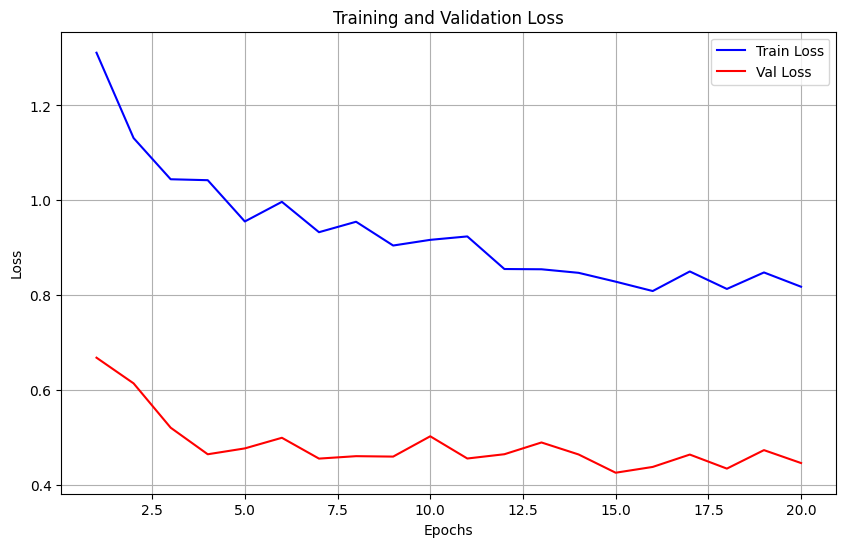

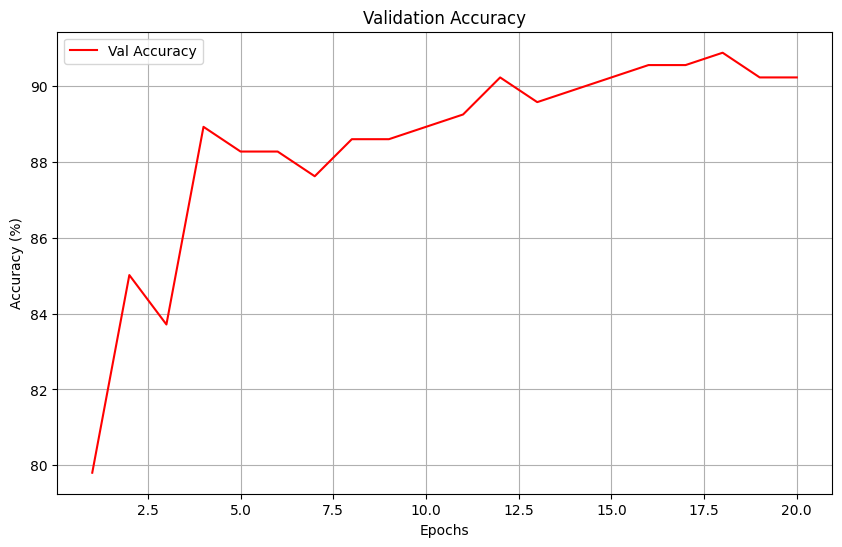

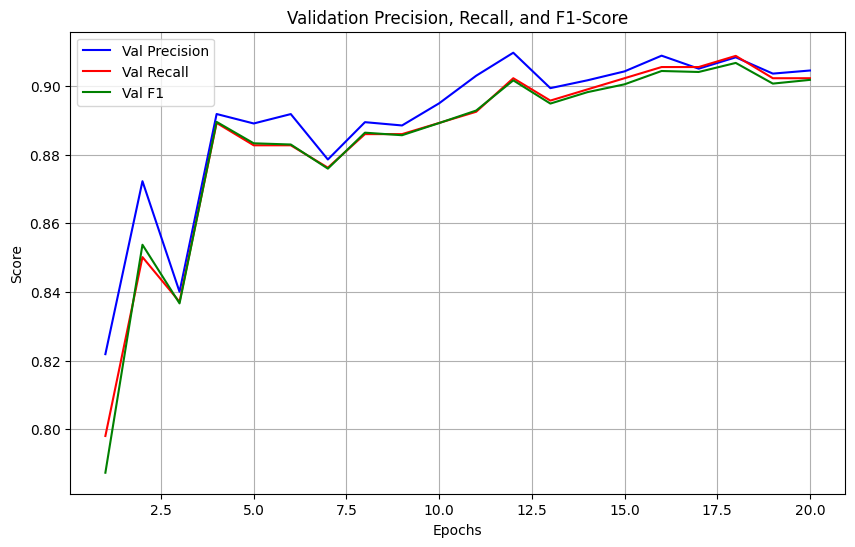

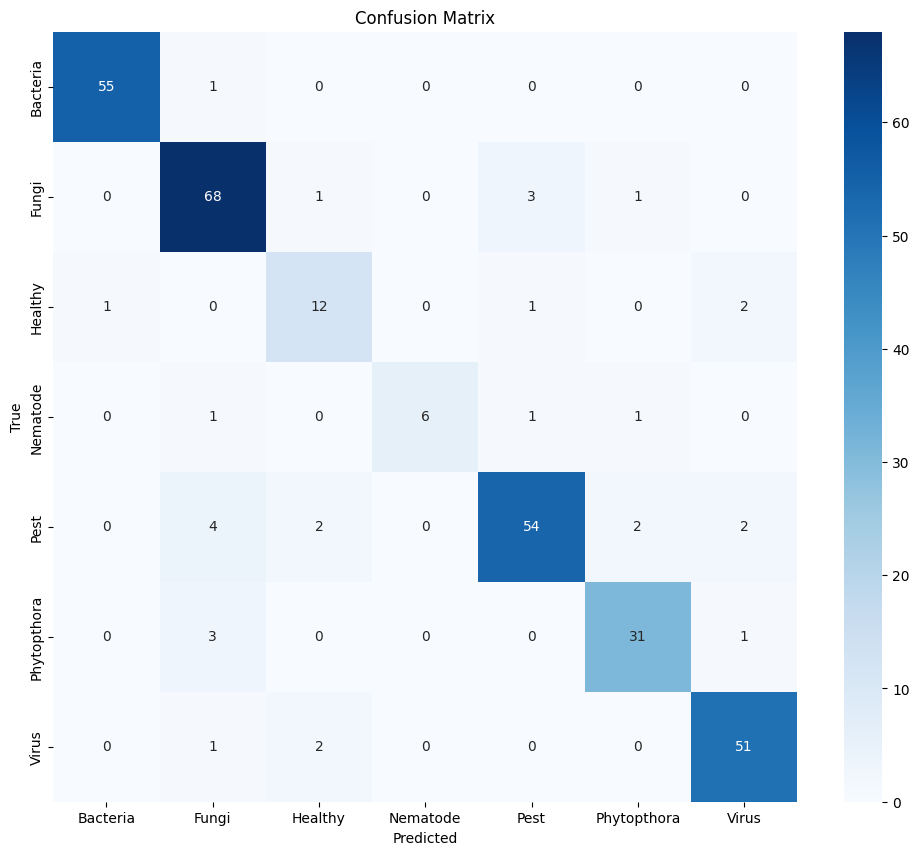

Final model saved.


2025-07-13 13:03:54,087 - INFO - Test Accuracy: 89.64%, Test Precision: 0.8983, Test Recall: 0.8964, Test F1: 0.8962



Test Accuracy: 89.64%  Precision: 0.8983  Recall: 0.8964  F1: 0.8962

Per-class metrics (Precision, Recall, F1) saved to Potato_Model_Output_DenseNetCBAM/per_class_report_densenet_cbam.csv

Per-class test metrics:
               precision    recall  f1-score    support
Bacteria       0.962264  0.980769  0.971429   52.00000
Fungi          0.871795  0.894737  0.883117   76.00000
Healthy        0.842105  0.800000  0.820513   20.00000
Nematode       1.000000  0.800000  0.888889   10.00000
Pest           0.857143  0.813559  0.834783   59.00000
Phytopthora    1.000000  0.914286  0.955224   35.00000
Virus          0.857143  0.947368  0.900000   57.00000
accuracy       0.896440  0.896440  0.896440    0.89644
macro avg      0.912921  0.878674  0.893422  309.00000
weighted avg   0.898268  0.896440  0.896166  309.00000

Sample predictions from test set:
True: Bacteria     | Pred: Bacteria    
True: Nematode     | Pred: Virus       
True: Phytopthora  | Pred: Phytopthora 
True: Phytopthora  | Pre

In [6]:
import pandas as pd
from sklearn.metrics import precision_recall_fscore_support, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import torch.nn.functional as F
import numpy as np

def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, num_epochs, device, early_stopping, variant, output_dir):
    model.to(device)
    train_losses, val_losses = [], []
    val_accs, val_precisions, val_recalls, val_f1s = [], [], [], []
    epoch_summaries = []
    best_model_path = os.path.join(output_dir, f'{variant}_best.pt')

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0

        for images, labels in train_loader:
            valid_mask = labels != -1
            if not valid_mask.any():
                continue
            images, labels = images[valid_mask].to(device), labels[valid_mask].to(device)

            # MixUp (for train only!)
            if mixup_fn is not None:
                images, labels = mixup_fn(images, labels)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)

        train_loss = running_loss / len(train_loader.dataset)
        train_losses.append(train_loss)

        # ---- VALIDATION PHASE (always meaningful) ----
        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0
        val_preds, val_labels_ = [], []

        with torch.no_grad():
            for images, labels in val_loader:
                valid_mask = labels != -1
                if not valid_mask.any():
                    continue
                images, labels = images[valid_mask].to(device), labels[valid_mask].to(device)

                # Validation loss: one-hot labels (because criterion expects soft labels for MixUp)
                labels_one_hot = F.one_hot(labels, num_classes=len(class_names)).float().to(device)
                outputs = model(images)
                loss = criterion(outputs, labels_one_hot)
                val_loss += loss.item() * images.size(0)

                _, predicted = torch.max(outputs, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()
                val_preds.extend(predicted.cpu().numpy())
                val_labels_.extend(labels.cpu().numpy())

        val_loss = val_loss / val_total if val_total > 0 else float('inf')
        val_acc = 100 * val_correct / val_total if val_total > 0 else 0
        val_precision, val_recall, val_f1, _ = precision_recall_fscore_support(
            val_labels_, val_preds, average='weighted', zero_division=0
        )

        val_losses.append(val_loss)
        val_accs.append(val_acc)
        val_precisions.append(val_precision)
        val_recalls.append(val_recall)
        val_f1s.append(val_f1)

        # Save epoch summary (training metrics commented out)
        epoch_summary = {
            'epoch': epoch + 1,
            'train_loss': train_loss,
            'val_loss': val_loss,
            'val_accuracy': val_acc,
            'val_precision': val_precision,
            'val_recall': val_recall,
            'val_f1': val_f1
        }
        epoch_summaries.append(epoch_summary)
        print(f"Epoch {epoch + 1}: Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")

        early_stopping(val_loss, model)
        if early_stopping.early_stop:
            print("Early stopping triggered")
            break
        scheduler.step()

    # Save CSV
    epoch_df = pd.DataFrame(epoch_summaries)
    csv_path = os.path.join(output_dir, f'epoch_summary_{variant}.csv')
    epoch_df.to_csv(csv_path, index=False)
    print(f"Saved epoch summaries to {csv_path}")

    # Reload best model
    model.load_state_dict(torch.load(early_stopping.path, map_location=device))
    print("\nTraining complete! Model reloaded from best checkpoint.")

    # PLOTS
    plt.figure(figsize=(10, 6))
    plt.plot(range(1, len(train_losses)+1), train_losses, 'b-', label='Train Loss')
    plt.plot(range(1, len(val_losses)+1), val_losses, 'r-', label='Val Loss')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.savefig(os.path.join(output_dir, f'loss_plot_{variant}.png'))
    plt.show()
    plt.close()

    plt.figure(figsize=(10, 6))
    plt.plot(range(1, len(val_accs)+1), val_accs, 'r-', label='Val Accuracy')
    plt.title('Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy (%)')
    plt.legend()
    plt.grid(True)
    plt.savefig(os.path.join(output_dir, f'accuracy_plot_{variant}.png'))
    plt.show()
    plt.close()

    plt.figure(figsize=(10, 6))
    plt.plot(range(1, len(val_precisions)+1), val_precisions, 'b-', label='Val Precision')
    plt.plot(range(1, len(val_recalls)+1), val_recalls, 'r-', label='Val Recall')
    plt.plot(range(1, len(val_f1s)+1), val_f1s, 'g-', label='Val F1')
    plt.title('Validation Precision, Recall, and F1-Score')
    plt.xlabel('Epochs')
    plt.ylabel('Score')
    plt.legend()
    plt.grid(True)
    plt.savefig(os.path.join(output_dir, f'prf1_plot_{variant}.png'))
    plt.show()
    plt.close()

    cm = confusion_matrix(val_labels_, val_preds)
    plt.figure(figsize=(12, 10))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.savefig(os.path.join(output_dir, f'confusion_matrix_{variant}.png'))
    plt.show()
    plt.close()

    return model

# ====== Run Training ======
num_epochs = 20  # For DenseNet201 as you requested
variant = 'densenet_cbam'
trained_model = train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, num_epochs, device, early_stopping, variant, output_dir)

# SAVE FINAL
torch.save(trained_model.state_dict(), os.path.join(output_dir, f"{variant}_final.pt"))
print("Final model saved.")

# ==== Evaluate on Test Set (with per-class metrics) ====
test_preds, test_labels = [], []
trained_model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        valid_mask = labels != -1
        if not valid_mask.any():
            continue
        images, labels = images[valid_mask].to(device), labels[valid_mask].to(device)
        outputs = trained_model(images)
        _, predicted = torch.max(outputs, 1)
        test_preds.extend(predicted.cpu().numpy())
        test_labels.extend(labels.cpu().numpy())

test_acc = 100 * np.mean(np.array(test_preds) == np.array(test_labels))
test_precision, test_recall, test_f1, _ = precision_recall_fscore_support(
    test_labels, test_preds, average='weighted', zero_division=0
)
print(f"\nTest Accuracy: {test_acc:.2f}%  Precision: {test_precision:.4f}  Recall: {test_recall:.4f}  F1: {test_f1:.4f}")
logger.info(f"Test Accuracy: {test_acc:.2f}%, Test Precision: {test_precision:.4f}, Test Recall: {test_recall:.4f}, Test F1: {test_f1:.4f}")

# ----- Per-class report -----
report = classification_report(test_labels, test_preds, target_names=class_names, output_dict=True, zero_division=0)
report_df = pd.DataFrame(report).transpose()
per_class_csv = os.path.join(output_dir, f'per_class_report_{variant}.csv')
report_df.to_csv(per_class_csv)
print(f"\nPer-class metrics (Precision, Recall, F1) saved to {per_class_csv}")
print("\nPer-class test metrics:\n", report_df)

# ---- Show a few test set predictions ----
print("\nSample predictions from test set:")
for idx in np.random.choice(len(test_labels), 5, replace=False):
    print(f"True: {class_names[test_labels[idx]]:12s} | Pred: {class_names[test_preds[idx]]:12s}")



 Save Teacher Model Checkpoint to Google Drive

In [7]:
# === After training finishes and best checkpoint exists ===
import shutil
import os

# Path to your best teacher model checkpoint
teacher_checkpoint = os.path.join(output_dir, f"{variant}_best.pt")

# Destination path in your Google Drive
drive_dest_folder = '/content/drive/My Drive/Research/PotatoTeacherModels'
os.makedirs(drive_dest_folder, exist_ok=True)

# You can make the filename more descriptive if you want
drive_checkpoint_path = os.path.join(drive_dest_folder, f"{variant}_best.pt")

# Copy the checkpoint to Google Drive
shutil.copy(teacher_checkpoint, drive_checkpoint_path)
print(f"Teacher model checkpoint saved to {drive_checkpoint_path}")


Teacher model checkpoint saved to /content/drive/My Drive/Research/PotatoTeacherModels/densenet_cbam_best.pt


Load Teacher Model from Google Drive, Define Student Model

In [11]:
# ==== Step 1: Teacher & Student Model Setup for KD (DenseNet201 + CBAM / MobileNetV2) ====

import os
import torch
import torch.nn as nn
import timm

# --- CBAM Module (Paste your trusted CBAM code here; using standard version) ---
class BasicConv(nn.Module):
    def __init__(self, in_planes, out_planes, kernel_size, stride, padding=0, dilation=1, groups=1, relu=True, bn=True, bias=False):
        super().__init__()
        self.conv = nn.Conv2d(in_planes, out_planes, kernel_size, stride, padding, dilation, groups, bias)
        self.bn = nn.BatchNorm2d(out_planes) if bn else None
        self.relu = nn.ReLU(inplace=True) if relu else None
    def forward(self, x):
        x = self.conv(x)
        if self.bn is not None: x = self.bn(x)
        if self.relu is not None: x = self.relu(x)
        return x

class ChannelAttention(nn.Module):
    def __init__(self, in_planes, ratio=8):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)
        self.fc1 = nn.Conv2d(in_planes, in_planes // ratio, 1, bias=False)
        self.relu1 = nn.ReLU()
        self.fc2 = nn.Conv2d(in_planes // ratio, in_planes, 1, bias=False)
        self.sigmoid = nn.Sigmoid()
    def forward(self, x):
        avg_out = self.fc2(self.relu1(self.fc1(self.avg_pool(x))))
        max_out = self.fc2(self.relu1(self.fc1(self.max_pool(x))))
        out = avg_out + max_out
        return self.sigmoid(out)

class SpatialAttention(nn.Module):
    def __init__(self, kernel_size=7):
        super().__init__()
        padding = 3 if kernel_size == 7 else 1
        self.conv1 = nn.Conv2d(2, 1, kernel_size, padding=padding, bias=False)
        self.sigmoid = nn.Sigmoid()
    def forward(self, x):
        avg_out = torch.mean(x, dim=1, keepdim=True)
        max_out, _ = torch.max(x, dim=1, keepdim=True)
        x = torch.cat([avg_out, max_out], dim=1)
        x = self.conv1(x)
        return self.sigmoid(x)

class CBAM(nn.Module):
    def __init__(self, in_planes, ratio=8, kernel_size=7):
        super().__init__()
        self.ca = ChannelAttention(in_planes, ratio)
        self.sa = SpatialAttention(kernel_size)
    def forward(self, x):
        x = x * self.ca(x)
        x = x * self.sa(x)
        return x

# --- Teacher Model: DenseNet201 + CBAM ---
class DenseNetCBAM(nn.Module):
    def __init__(self, num_classes=7, dropout=0.5):
        super().__init__()
        self.base = timm.create_model('densenet201', pretrained=False, num_classes=0, drop_rate=dropout)
        self.cbam = CBAM(in_planes=1920)
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.head = nn.Linear(1920, num_classes)
    def forward(self, x):
        features = self.base.forward_features(x)
        features = self.cbam(features)
        pooled = self.pool(features).flatten(1)
        out = self.head(pooled)
        return out

# --- Student Model: MobileNetV2 (smaller, fast, strong baseline) ---
class MobileNetV2Custom(nn.Module):
    def __init__(self, num_classes=7, dropout=0.2):
        super().__init__()
        self.base = timm.create_model('mobilenetv2_100', pretrained=True, num_classes=0, drop_rate=dropout)
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.head = nn.Linear(self.base.num_features, num_classes)
    def forward(self, x):
        x = self.base.forward_features(x)
        x = self.pool(x).flatten(1)
        x = self.head(x)
        return x

# ---- DEVICE ----
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ---- Load Teacher Model from Google Drive ----
teacher_weights_path = '/content/drive/My Drive/Research/PotatoTeacherModels/densenet_cbam_best.pt'
teacher_model = DenseNetCBAM(num_classes=7, dropout=0.5).to(device)
teacher_model.load_state_dict(torch.load(teacher_weights_path, map_location=device))
teacher_model.eval()
print("Teacher model loaded from Google Drive!")

# ---- Init Student Model (MobileNetV2) ----
student_model = MobileNetV2Custom(num_classes=7, dropout=0.2).to(device)
print("Student model (MobileNetV2) initialized.")

# ---- Model Size Utility ----
def get_model_size(model):
    torch.save(model.state_dict(), "temp.p")
    size = os.path.getsize("temp.p") / 1e6  # MB
    os.remove("temp.p")
    return size

print(f"Teacher model size: {get_model_size(teacher_model):.2f} MB")
print(f"Student model size: {get_model_size(student_model):.2f} MB")

# ---- Inference Speed Utility ----
def measure_inference_speed(model, device, input_size=(1, 3, 224, 224), runs=50):
    import time
    model.eval()
    dummy = torch.randn(*input_size).to(device)
    # Warm-up
    for _ in range(10): _ = model(dummy)
    # Timing
    start = time.time()
    for _ in range(runs): _ = model(dummy)
    end = time.time()
    avg_time = (end - start) / runs * 1000  # ms per inference
    return avg_time

print(f"Teacher inference speed: {measure_inference_speed(teacher_model, device):.2f} ms/img")
print(f"Student inference speed: {measure_inference_speed(student_model, device):.2f} ms/img")


2025-07-13 14:15:22,632 - INFO - Loading pretrained weights from Hugging Face hub (timm/mobilenetv2_100.ra_in1k)


Teacher model loaded from Google Drive!


model.safetensors:   0%|          | 0.00/14.2M [00:00<?, ?B/s]

2025-07-13 14:15:23,011 - INFO - [timm/mobilenetv2_100.ra_in1k] Safe alternative available for 'pytorch_model.bin' (as 'model.safetensors'). Loading weights using safetensors.


Student model (MobileNetV2) initialized.
Teacher model size: 77.44 MB
Student model size: 9.16 MB
Teacher inference speed: 37.77 ms/img
Student inference speed: 8.94 ms/img


KD Training Loop and Evaluation for MobileNetV3-Small

Epoch 1: Train Loss: 0.8065, Val Loss: 0.4624, Val Acc: 78.50%
Validation loss decreased (inf --> 0.4624). Saving model ...
Epoch 2: Train Loss: 0.4091, Val Loss: 0.3716, Val Acc: 82.41%
Validation loss decreased (0.4624 --> 0.3716). Saving model ...
Epoch 3: Train Loss: 0.2864, Val Loss: 0.3421, Val Acc: 87.62%
Validation loss decreased (0.3716 --> 0.3421). Saving model ...
Epoch 4: Train Loss: 0.2217, Val Loss: 0.3252, Val Acc: 85.34%
Validation loss decreased (0.3421 --> 0.3252). Saving model ...
Epoch 5: Train Loss: 0.1851, Val Loss: 0.3003, Val Acc: 86.32%
Validation loss decreased (0.3252 --> 0.3003). Saving model ...
Epoch 6: Train Loss: 0.1586, Val Loss: 0.3211, Val Acc: 83.06%
EarlyStopping counter: 1 out of 10
Epoch 7: Train Loss: 0.1396, Val Loss: 0.3083, Val Acc: 86.32%
EarlyStopping counter: 2 out of 10
Epoch 8: Train Loss: 0.1305, Val Loss: 0.2820, Val Acc: 87.62%
Validation loss decreased (0.3003 --> 0.2820). Saving model ...
Epoch 9: Train Loss: 0.1163, Val Loss: 0.2713

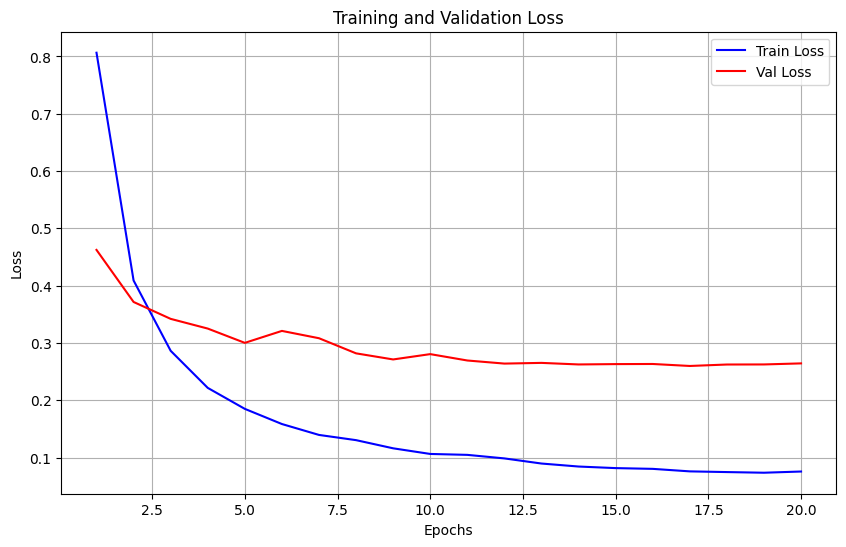

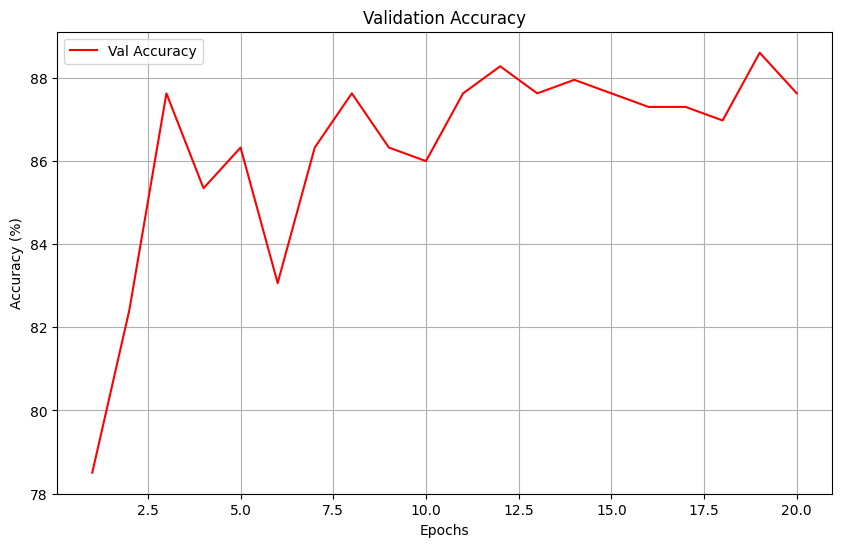

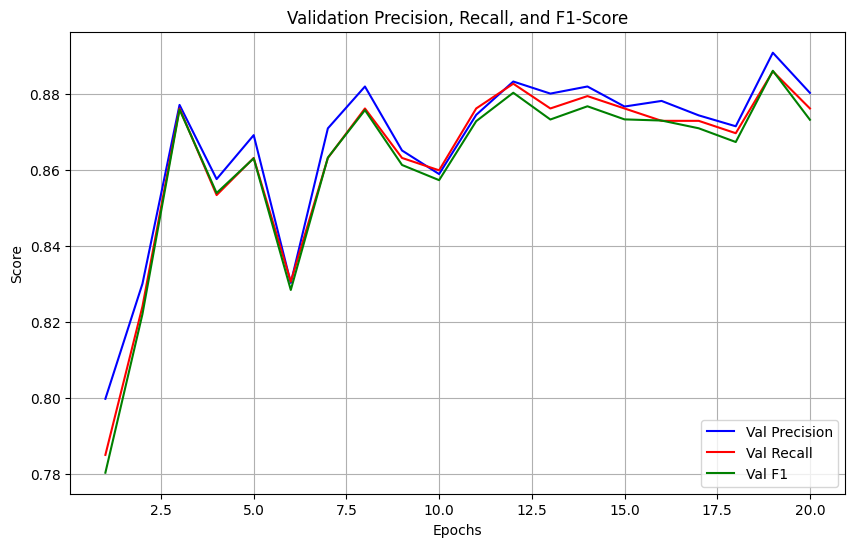

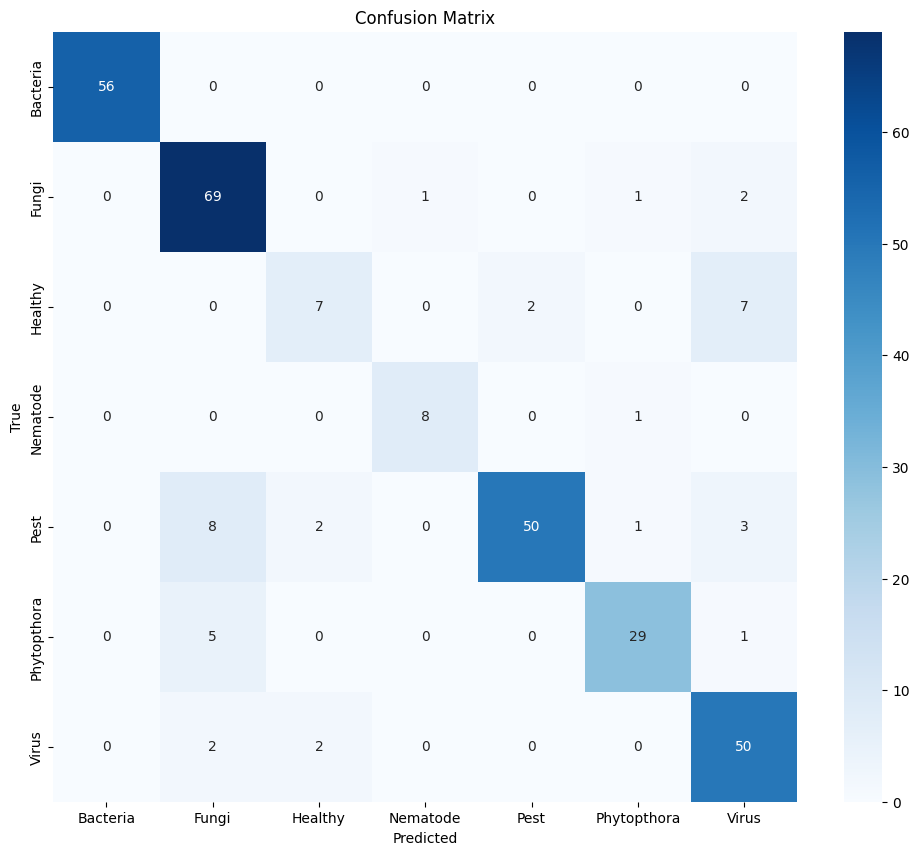

Final student model saved.


2025-07-13 14:45:28,668 - INFO - Test Accuracy: 87.06%, Test Precision: 0.8751, Test Recall: 0.8706, Test F1: 0.8717



Test Accuracy: 87.06%  Precision: 0.8751  Recall: 0.8706  F1: 0.8717

Per-class metrics (Precision, Recall, F1) saved to Potato_Model_Output_DenseNetCBAM/per_class_report_mobilenetv2_kd.csv

Per-class test metrics:
               precision    recall  f1-score    support
Bacteria       1.000000  0.980769  0.990291   52.00000
Fungi          0.790123  0.842105  0.815287   76.00000
Healthy        0.666667  0.800000  0.727273   20.00000
Nematode       1.000000  0.900000  0.947368   10.00000
Pest           0.849057  0.762712  0.803571   59.00000
Phytopthora    0.941176  0.914286  0.927536   35.00000
Virus          0.912281  0.912281  0.912281   57.00000
accuracy       0.870550  0.870550  0.870550    0.87055
macro avg      0.879901  0.873165  0.874801  309.00000
weighted avg   0.875140  0.870550  0.871685  309.00000

Sample predictions from test set:
True: Virus        | Pred: Healthy     
True: Bacteria     | Pred: Bacteria    
True: Virus        | Pred: Virus       
True: Fungi        | Pr

In [12]:
import torch
import torch.nn.functional as F
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import precision_recall_fscore_support, confusion_matrix, classification_report

# --- KD Loss Function: Cross-Entropy + Soft (KL) Divergence ---
def kd_loss(student_logits, teacher_logits, targets, alpha=0.7, T=4.0):
    # KD Loss (soft targets, higher temperature)
    log_student_soft = F.log_softmax(student_logits / T, dim=1)
    teacher_soft = F.softmax(teacher_logits / T, dim=1)
    kd_loss = F.kl_div(log_student_soft, teacher_soft, reduction='batchmean') * (T * T)
    ce_loss = F.cross_entropy(student_logits, targets)
    return alpha * kd_loss + (1 - alpha) * ce_loss

# --- Training Loop ---
def train_kd(
    student_model, teacher_model,
    train_loader, val_loader,
    optimizer, scheduler, num_epochs,
    device, early_stopping, variant, output_dir,
    alpha=0.7, T=4.0
):
    student_model.to(device)
    teacher_model.to(device)
    teacher_model.eval()

    train_losses, val_losses = [], []
    val_accs, val_precisions, val_recalls, val_f1s = [], [], [], []
    epoch_summaries = []
    best_model_path = os.path.join(output_dir, f'{variant}_best.pt')

    for epoch in range(num_epochs):
        student_model.train()
        running_loss = 0.0

        for images, labels in train_loader:
            valid_mask = labels != -1
            if not valid_mask.any():
                continue
            images, labels = images[valid_mask].to(device), labels[valid_mask].to(device)

            # Get teacher outputs (no grad, faster)
            with torch.no_grad():
                teacher_logits = teacher_model(images)
            student_logits = student_model(images)
            loss = kd_loss(student_logits, teacher_logits, labels, alpha=alpha, T=T)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)

        train_loss = running_loss / len(train_loader.dataset)
        train_losses.append(train_loss)

        # ---- VALIDATION PHASE ----
        student_model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0
        val_preds, val_labels_ = [], []

        with torch.no_grad():
            for images, labels in val_loader:
                valid_mask = labels != -1
                if not valid_mask.any():
                    continue
                images, labels = images[valid_mask].to(device), labels[valid_mask].to(device)
                teacher_logits = teacher_model(images)
                student_logits = student_model(images)
                loss = kd_loss(student_logits, teacher_logits, labels, alpha=alpha, T=T)
                val_loss += loss.item() * images.size(0)
                _, predicted = torch.max(student_logits, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()
                val_preds.extend(predicted.cpu().numpy())
                val_labels_.extend(labels.cpu().numpy())

        val_loss = val_loss / val_total if val_total > 0 else float('inf')
        val_acc = 100 * val_correct / val_total if val_total > 0 else 0
        val_precision, val_recall, val_f1, _ = precision_recall_fscore_support(
            val_labels_, val_preds, average='weighted', zero_division=0
        )

        val_losses.append(val_loss)
        val_accs.append(val_acc)
        val_precisions.append(val_precision)
        val_recalls.append(val_recall)
        val_f1s.append(val_f1)

        # Save epoch summary
        epoch_summary = {
            'epoch': epoch + 1,
            'train_loss': train_loss,
            'val_loss': val_loss,
            'val_accuracy': val_acc,
            'val_precision': val_precision,
            'val_recall': val_recall,
            'val_f1': val_f1
        }
        epoch_summaries.append(epoch_summary)
        print(f"Epoch {epoch + 1}: Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")

        early_stopping(val_loss, student_model)
        if early_stopping.early_stop:
            print("Early stopping triggered")
            break
        scheduler.step()

    # Save CSV
    epoch_df = pd.DataFrame(epoch_summaries)
    csv_path = os.path.join(output_dir, f'epoch_summary_{variant}.csv')
    epoch_df.to_csv(csv_path, index=False)
    print(f"Saved epoch summaries to {csv_path}")

    # Reload best model
    student_model.load_state_dict(torch.load(early_stopping.path, map_location=device))
    print("\nTraining complete! Student model reloaded from best checkpoint.")

    # PLOTS
    plt.figure(figsize=(10, 6))
    plt.plot(range(1, len(train_losses)+1), train_losses, 'b-', label='Train Loss')
    plt.plot(range(1, len(val_losses)+1), val_losses, 'r-', label='Val Loss')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.savefig(os.path.join(output_dir, f'loss_plot_{variant}.png'))
    plt.show()
    plt.close()

    plt.figure(figsize=(10, 6))
    plt.plot(range(1, len(val_accs)+1), val_accs, 'r-', label='Val Accuracy')
    plt.title('Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy (%)')
    plt.legend()
    plt.grid(True)
    plt.savefig(os.path.join(output_dir, f'accuracy_plot_{variant}.png'))
    plt.show()
    plt.close()

    plt.figure(figsize=(10, 6))
    plt.plot(range(1, len(val_precisions)+1), val_precisions, 'b-', label='Val Precision')
    plt.plot(range(1, len(val_recalls)+1), val_recalls, 'r-', label='Val Recall')
    plt.plot(range(1, len(val_f1s)+1), val_f1s, 'g-', label='Val F1')
    plt.title('Validation Precision, Recall, and F1-Score')
    plt.xlabel('Epochs')
    plt.ylabel('Score')
    plt.legend()
    plt.grid(True)
    plt.savefig(os.path.join(output_dir, f'prf1_plot_{variant}.png'))
    plt.show()
    plt.close()

    cm = confusion_matrix(val_labels_, val_preds)
    plt.figure(figsize=(12, 10))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.savefig(os.path.join(output_dir, f'confusion_matrix_{variant}.png'))
    plt.show()
    plt.close()

    return student_model

# ====== Run KD Training ======
num_epochs = 20
variant = 'mobilenetv2_kd'   # For MobileNetV2 KD
optimizer = torch.optim.AdamW(filter(lambda p: p.requires_grad, student_model.parameters()), lr=3e-4, weight_decay=0.01)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)
early_stopping = EarlyStopping(patience=10, verbose=True, path=os.path.join(output_dir, f"{variant}_best.pt"))

trained_student = train_kd(
    student_model, teacher_model,
    train_loader, val_loader,
    optimizer, scheduler, num_epochs,
    device, early_stopping, variant, output_dir,
    alpha=0.7, T=4.0
)

# SAVE FINAL
torch.save(trained_student.state_dict(), os.path.join(output_dir, f"{variant}_final.pt"))
print("Final student model saved.")

# ==== Evaluate on Test Set (with per-class metrics) ====
test_preds, test_labels = [], []
trained_student.eval()
with torch.no_grad():
    for images, labels in test_loader:
        valid_mask = labels != -1
        if not valid_mask.any():
            continue
        images, labels = images[valid_mask].to(device), labels[valid_mask].to(device)
        outputs = trained_student(images)
        _, predicted = torch.max(outputs, 1)
        test_preds.extend(predicted.cpu().numpy())
        test_labels.extend(labels.cpu().numpy())

test_acc = 100 * np.mean(np.array(test_preds) == np.array(test_labels))
test_precision, test_recall, test_f1, _ = precision_recall_fscore_support(
    test_labels, test_preds, average='weighted', zero_division=0
)
print(f"\nTest Accuracy: {test_acc:.2f}%  Precision: {test_precision:.4f}  Recall: {test_recall:.4f}  F1: {test_f1:.4f}")
logger.info(f"Test Accuracy: {test_acc:.2f}%, Test Precision: {test_precision:.4f}, Test Recall: {test_recall:.4f}, Test F1: {test_f1:.4f}")

# ----- Per-class report -----
report = classification_report(test_labels, test_preds, target_names=class_names, output_dict=True, zero_division=0)
report_df = pd.DataFrame(report).transpose()
per_class_csv = os.path.join(output_dir, f'per_class_report_{variant}.csv')
report_df.to_csv(per_class_csv)
print(f"\nPer-class metrics (Precision, Recall, F1) saved to {per_class_csv}")
print("\nPer-class test metrics:\n", report_df)

# ---- Show a few test set predictions ----
print("\nSample predictions from test set:")
for idx in np.random.choice(len(test_labels), 5, replace=False):
    print(f"True: {class_names[test_labels[idx]]:12s} | Pred: {class_names[test_preds[idx]]:12s}")

# ---- Save Student Model Size & Inference Speed ----
student_mb = get_model_size(trained_student)
student_inf_ms = measure_inference_speed(trained_student, device)
with open(os.path.join(output_dir, f'{variant}_size_speed.txt'), 'w') as f:
    f.write(f"Model size: {student_mb:.2f} MB\nInference speed: {student_inf_ms:.2f} ms/img\n")
print(f"Student size: {student_mb:.2f} MB | Speed: {student_inf_ms:.2f} ms/img")
